#Homework 4: From Model to Production — End-to-End MLOps Pipeline

**PART 5 - Monitoring & Drift Detection**

In [ ]:
!pip install scipy scikit-learn lightgbm pandas numpy matplotlib seaborn joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Trained HW2 model
model = joblib.load('/content/drive/MyDrive/Data6545/model.pkl')
print("Model loaded:", type(model).__name__)

#integrated dataset
df_model = pd.read_csv("/content/drive/MyDrive/final_df_model.csv")
print("Dataset shape:", df_model.shape)

Model loaded: Pipeline
Dataset shape: (98673, 14)


In [ ]:
print(df_model.columns.tolist())

['delivery_days', 'delivery_vs_estimated', 'freight_value', 'product_category_name', 'seller_state', 'payment_type_main', 'seller_historical_average_rating', 'is_new_seller', 'num_items', 'payment_value_total', 'order_hour', 'order_dayofweek', 'is_positive_review', 'freight_ratio']


In [ ]:
features = ['delivery_days', 'delivery_vs_estimated', 'freight_value',
            'product_category_name', 'seller_state', 'payment_type_main',
            'seller_historical_average_rating', 'is_new_seller',
            'num_items', 'payment_value_total', 'order_hour', 'order_dayofweek']

numeric_features = ['delivery_days', 'delivery_vs_estimated', 'freight_value',
                    'seller_historical_average_rating', 'is_new_seller',
                    'num_items', 'payment_value_total', 'order_hour']

target = "is_positive_review"

#df model is my reference
ref_data = df_model.copy()

print(f"Reference data shape: {ref_data.shape}")
print(f"Positive reviews: {ref_data[target].sum()}")
print(f"Negative reviews: {ref_data.shape[0] - ref_data[target].sum()}")

Reference data shape: (98673, 14)
Positive reviews: 76044
Negative reviews: 22629


In [ ]:
#Part 5A Production Data Simulation - create simulated production by modifying HW2 data. add onth column (1-6) to track periods.

def simulate_month(ref_data, month, features, n_samples = 3000):
    sample = ref_data.sample(n=n_samples, replace = True, random_state=42 + month).copy()
    sample = sample.reset_index(drop = True)

    for col in numeric_features:
      noise = np.random.normal(1.0, 0.05, len(sample))
      sample[col] = (sample[col] * noise)

    if month >= 4:
        drift_level = month - 3

        # +2 days (Month 4=+2, Month 5=+4, Month 6=+6)
        sample['delivery_days'] = sample['delivery_days'] + (2 * drift_level)

        # freight_value: Month4=+15%, Month5=+30%, Month6=+50%
        freight_increases = {1: 0.15, 2: 0.30, 3: 0.50}
        sample['freight_value'] = sample['freight_value'] * (1 + freight_increases[drift_level])

        # Flip 5% positive → negative each drift month
        positive_idx = sample[sample[target] == 1].index
        n_flip = int(len(positive_idx) * 0.05)
        if n_flip > 0:
            flip_idx = np.random.choice(positive_idx,
                                        size=min(n_flip, len(positive_idx)),
                                        replace=False)
            sample.loc[flip_idx, target] = 0

    sample['month'] = month
    return sample


In [ ]:
#generate 6 months

np.random.seed(42)
production = pd.concat([simulate_month(ref_data, month, features) for month in range(1, 7)], ignore_index=True)

print(f"Total production records: {len(production)}")
print(f"\nRecords per month:")
print(production['month'].value_counts().sort_index())
print(f"\nPositive review rate per month:")

for month in range(1, 7):
    rate = production[production['month'] == month][target].mean()
    marker = " <- drift starts" if m == 4 else ""
    print(f"  Month {month}: {rate:.3f}{marker}")

Total production records: 18000

Records per month:
month
1    3000
2    3000
3    3000
4    3000
5    3000
6    3000
Name: count, dtype: int64

Positive review rate per month:
  Month 1: 0.754
  Month 2: 0.763
  Month 3: 0.766
  Month 4: 0.746
  Month 5: 0.732
  Month 6: 0.720


In [ ]:
#Part 5B Statistical Drift Detection
#PSI
def calculate_psi(reference, current, bins = 10):
    breakpoints = np.linspace(
        min(reference.min(), current.min()),
        max(reference.max(), current.max()),
        bins + 1
    )
    ref_counts = np.histogram(reference, bins=breakpoints)[0]
    cur_counts = np.histogram(current, bins=breakpoints)[0]

    ref_pct = ref_counts / len(reference) + 1e-4
    cur_pct = cur_counts / len(current) + 1e-4

    psi = np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct))
    return round(psi, 4)

def interpret_psi(val):
  if val < 0.1:
      return "Stable"
  elif val < 0.2:
      return "Moderate"
  else:
      return "Significant"

psi_features = ['delivery_days', 'delivery_vs_estimated',
                'freight_value', 'payment_value_total', 'order_hour']

psi_results = {}

for feature in psi_features:
    psi_results[feature] = {}
    for month in range(1, 7):
        month_data = production[production['month'] == month][feature]
        psi_results[feature][month] = calculate_psi(ref_data[feature], month_data)


#Display
psi_df = pd.DataFrame(psi_results).T
psi_df.columns = [f"Month {m}" for m in range(1, 7)]

print("PSI Results (Reference vs Each Month)")
print("=" * 70)
print(psi_df.round(4).to_string())

PSI Results (Reference vs Each Month)
                       Month 1  Month 2  Month 3  Month 4  Month 5  Month 6
delivery_days           0.0013   0.0018   0.0012   0.0048   0.0435   0.0986
delivery_vs_estimated   0.0065   0.0089   0.0087   0.0089   0.0051   0.0060
freight_value           0.0016   0.0009   0.0026   0.0067   0.0318   0.0569
payment_value_total     0.0003   0.0005   0.0012   0.0007   0.0015   0.0009
order_hour              0.0314   0.1056   0.0742   0.2028   0.2003   0.0989


In [ ]:
#Summary Table
def color_psi(val):
    if val < 0.1:
        return 'background-color: #90EE90'  # green - stable
    elif val < 0.2:
        return 'background-color: #FFD700'  # yellow - moderate
    else:
        return 'background-color: #FF6B6B'  # red - significant

styled_psi = psi_df.style.applymap(color_psi)
styled_psi.set_caption("PSI Results — Color Coded by Severity")
display(styled_psi)

print("\nLegend:")
print("  Green  = PSI < 0.1  → Stable")
print("  Yellow = PSI 0.1-0.2 → Moderate drift, investigate")
print("  Red    = PSI >= 0.2  → Significant drift, action required")

,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6
delivery_days,0.001300,0.001800,0.001200,0.004800,0.043500,0.098600
delivery_vs_estimated,0.006500,0.008900,0.008700,0.008900,0.005100,0.006000
freight_value,0.001600,0.000900,0.002600,0.006700,0.031800,0.056900
payment_value_total,0.000300,0.000500,0.001200,0.000700,0.001500,0.000900
order_hour,0.031400,0.105600,0.074200,0.202800,0.200300,0.098900



Legend:
  Green  = PSI < 0.1  → Stable
  Yellow = PSI 0.1-0.2 → Moderate drift, investigate
  Red    = PSI >= 0.2  → Significant drift, action required


For the KS Test, I chose to drop missing values to keep the analysis focused on completed orders. In a real production environment like Olist, I would first investigate the root cause of the missing values before dropping them, as they could indicate cancelled orders, lost shipments, or data quality issues. For the purpose of this analysis, dropping them is best.

In [ ]:
#KS Test
ks_results = {}
for feature in psi_features:
    ks_results[feature] = {}
    print(f"\n{feature}:")
    for month in range(1, 7):
        month_data = production[production['month'] == month][feature].dropna()
        ref_feature = ref_data[feature].dropna()

        stat, pval = ks_2samp(ref_feature, month_data)
        ks_results[feature][month] = {
            'statistic': round(stat, 4),
            'pvalue': round(pval, 4)
        }
        sig = "*** SIGNIFICANT" if pval < 0.05 else ""
        print(f"  Month {month}: KS={stat:.4f}, p={pval:.4f} {sig}")


delivery_days:
  Month 1: KS=0.0468, p=0.0000 *** SIGNIFICANT
  Month 2: KS=0.0426, p=0.0001 *** SIGNIFICANT
  Month 3: KS=0.0485, p=0.0000 *** SIGNIFICANT
  Month 4: KS=0.1864, p=0.0000 *** SIGNIFICANT
  Month 5: KS=0.3099, p=0.0000 *** SIGNIFICANT
  Month 6: KS=0.4291, p=0.0000 *** SIGNIFICANT

delivery_vs_estimated:
  Month 1: KS=0.0510, p=0.0000 *** SIGNIFICANT
  Month 2: KS=0.0466, p=0.0000 *** SIGNIFICANT
  Month 3: KS=0.0527, p=0.0000 *** SIGNIFICANT
  Month 4: KS=0.0495, p=0.0000 *** SIGNIFICANT
  Month 5: KS=0.0371, p=0.0008 *** SIGNIFICANT
  Month 6: KS=0.0430, p=0.0001 *** SIGNIFICANT

freight_value:
  Month 1: KS=0.0315, p=0.0065 *** SIGNIFICANT
  Month 2: KS=0.0283, p=0.0192 *** SIGNIFICANT
  Month 3: KS=0.0342, p=0.0023 *** SIGNIFICANT
  Month 4: KS=0.1877, p=0.0000 *** SIGNIFICANT
  Month 5: KS=0.3448, p=0.0000 *** SIGNIFICANT
  Month 6: KS=0.4579, p=0.0000 *** SIGNIFICANT

payment_value_total:
  Month 1: KS=0.0092, p=0.9627 
  Month 2: KS=0.0163, p=0.4187 
  Month 3: K

In [ ]:
#5C Performance Monitoring
X_prod = production[features]
production['pred'] = model.predict(X_prod)
production['pred_prob'] = model.predict_proba(X_prod)[:, 1]

monthly_metrics = []
for month in range(1, 7):
    mask = production['month'] == month
    y_true = production.loc[mask, target]
    y_pred = production.loc[mask, 'pred']
    y_prob = production.loc[mask, 'pred_prob']

    monthly_metrics.append({
        'Month': month,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1': round(f1_score(y_true, y_pred), 4),
        'AUC': round(roc_auc_score(y_true, y_prob), 4),
    })

metrics_df = pd.DataFrame(monthly_metrics).set_index('Month')
print("Monthly Performance Metrics")
print("=" * 50)
print(metrics_df.to_string())

# Performance drop
print(f"\nPerformance Drop (Month 1 → Month 6):")
for col in ['Accuracy', 'F1', 'AUC']:
    m1 = metrics_df.loc[1, col]
    m6 = metrics_df.loc[6, col]
    drop = m1 - m6
    pct = (drop / m1) * 100
    print(f"  {col}: {m1:.4f} → {m6:.4f} (↓{drop:.4f}, {pct:.1f}%)")

Monthly Performance Metrics
       Accuracy      F1     AUC
Month                          
1        0.7787  0.8546  0.7341
2        0.7677  0.8470  0.7357
3        0.7810  0.8561  0.7484
4        0.7293  0.8189  0.6846
5        0.7267  0.8111  0.7037
6        0.7117  0.7946  0.7236

Performance Drop (Month 1 → Month 6):
  Accuracy: 0.7787 → 0.7117 (↓0.0670, 8.6%)
  F1: 0.8546 → 0.7946 (↓0.0600, 7.0%)
  AUC: 0.7341 → 0.7236 (↓0.0105, 1.4%)


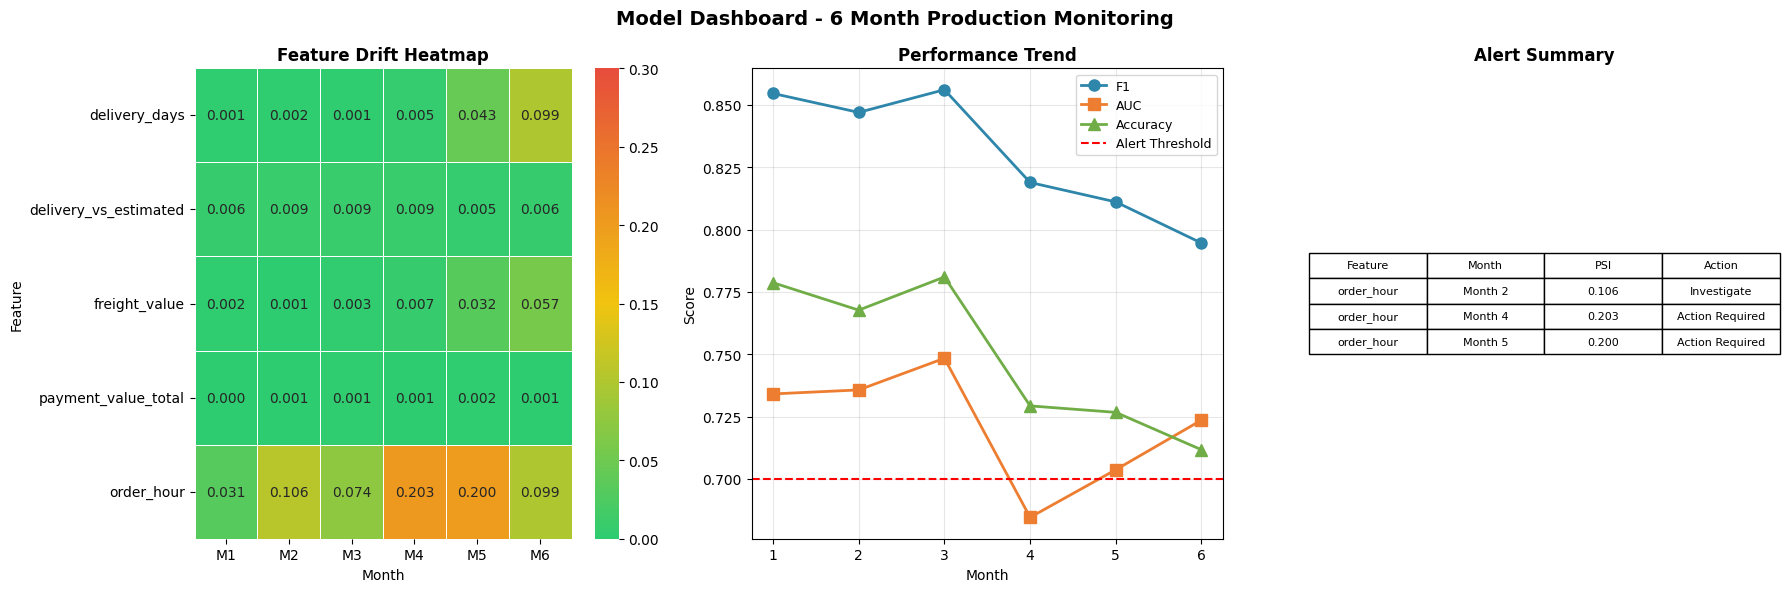

In [ ]:
#5D Monitoring Dashboard
fig, axes = plt.subplots(1,3, figsize = (18,6))
fig.suptitle("Model Dashboard - 6 Month Production Monitoring",
            fontsize = 14, fontweight = 'bold')

#Panel 1: Drift HeatMap
ax1 = axes[0]
import matplotlib.colors as mcolors

colors_list = ['#2ecc71', '#f1c40f', '#e74c3c']
cmap = mcolors.LinearSegmentedColormap.from_list('drift', colors_list, N=256)
sns.heatmap(psi_df.values.astype(float), ax=ax1, annot=True, fmt='.3f',
            cmap=cmap, vmin=0, vmax=0.3,
            xticklabels=[f'M{m}' for m in range(1, 7)],
            yticklabels=psi_features,
            linewidths=0.5)

ax1.set_title("Feature Drift Heatmap", fontweight = 'bold')
ax1.set_xlabel("Month")
ax1.set_ylabel("Feature")

#Panel 2: Performance Trend
ax2 = axes[1]
months = range(1, 7)
ax2.plot(months, metrics_df['F1'], 'o-', color='#2e86ab', lw=2, ms=8, label='F1')
ax2.plot(months, metrics_df['AUC'], 's-', color='#ed7d31', lw=2, ms=8, label='AUC')
ax2.plot(months, metrics_df['Accuracy'], '^-', color='#70ad47', lw=2, ms=8, label='Accuracy')
ax2.axhline(y=0.70, color='red', ls='--', lw=1.5, label='Alert Threshold')
ax2.set_title('Performance Trend', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Score')
ax2.set_xticks(range(1, 7))
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

#Panel 3: Alert Sumarry
ax3 = axes[2]
ax3.axis('off')
alert_data = []
for feature in psi_features:
    for month in range(1, 7):
        psi_val = psi_df.loc[feature, f'Month {month}']
        if psi_val >= 0.1:
            action = "Action Required" if psi_val >= 0.2 else "Investigate"
            alert_data.append([feature, f'Month {month}',
                              f'{psi_val:.3f}', action])

if alert_data:
    table = ax3.table(
        cellText=alert_data,
        colLabels=['Feature', 'Month', 'PSI', 'Action'],
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.5)
ax3.set_title('Alert Summary', fontweight='bold')

plt.tight_layout()
plt.show()


**Recommendation**

Based on the monitoring analysis, I would recommend retraining the model. The data has 2 different types of drifts, data drift and concept drift. There was an increase in PSI for month 4 for delivery days and freight value. And there was a decrease in positiive review rate dropped from Month 1 to Month 6. This can indicate that customers were becoming less satisfied with the same delivery conditions over time.

AUC remined relatively stable and consistent with only a 1.4% drop. Accuracy had a 8.6% drop and F1 had a 7% drop between Month 1 and Month 6. This was interesting to see because the model is still ranking customers correctly interms of riks, but the predictions are becoming less accurate and precise. For Olist, the model is still useful for identifying at risk customers, but the threshold for flagging dissatisfied customers might need to be adjusted.

I would recommend retraining when there is a significant drift / PSI is less than or equal to 0.2 for key delivery features or when accuracy and F1 drop more than 5%. Data that should be included in the retriaining should be recent data from the alst 6 months of production data. The model can capture new patterns in delivery times and freight costs. Our economy and external factors are always changing and we can never quite grasp how much, so it does make sense for the model to be retrained every couple months. I would also recommend engineering new features that can capture seasonal trends or other changes.

For Olist, every missed dissatisfied custoemr is a potenital loaa retention opportunity. Because there are already drifts and drops in PSI in Months 1-6, early retrianing would be less costly to stakeholders rather than dealing with negative reviews and lost customers.